In [1]:
import torch
import gpytorch
import numpy as np
from matplotlib import pyplot as plt

from GPR_MLIP.evaluation import extended_reliablility_diagram, plot_legend

In [2]:
train_x = torch.flatten(torch.stack([torch.rand(5)*0.05 + b for b in [0, 0.5, 1.1, 1.5, 1.8]]))
train_y = torch.sin(train_x * (2 * torch.pi)) + torch.randn(train_x.size()) * 0.002

In [3]:
class GPRegressionModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPRegressionModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPRegressionModel(train_x, train_y, likelihood)

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iterations = 50
for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()

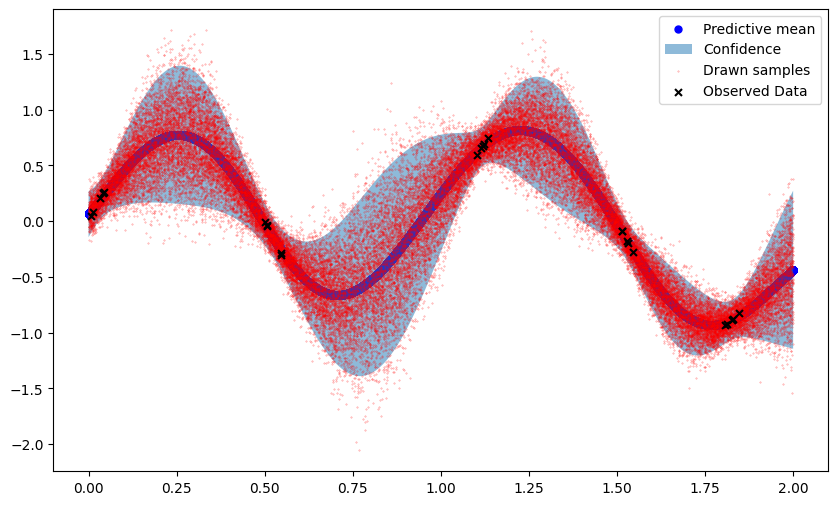

In [4]:
n_test_samples = 50000
n_gpr_samples = 1

model.eval()
likelihood.eval()

test_x = torch.rand(n_test_samples)*2
test_x = torch.sort(test_x)[0]

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))
    lower, upper = observed_pred.confidence_region()
    observed_pred = observed_pred.to_data_independent_dist()
    samples = observed_pred.sample(sample_shape=torch.Size((n_gpr_samples,)))

with torch.no_grad():
    f, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.scatter(test_x.numpy(), observed_pred.mean.numpy(), s=25, c='blue', label='Predictive mean')
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5, label='Confidence')
    ax.scatter(test_x.numpy(), samples.numpy(), s=0.1, alpha=0.5, c='red', label='Drawn samples')
    ax.scatter(train_x.numpy(), train_y.numpy(), s=25, marker='x', c='black', label='Observed Data')
    ax.legend()

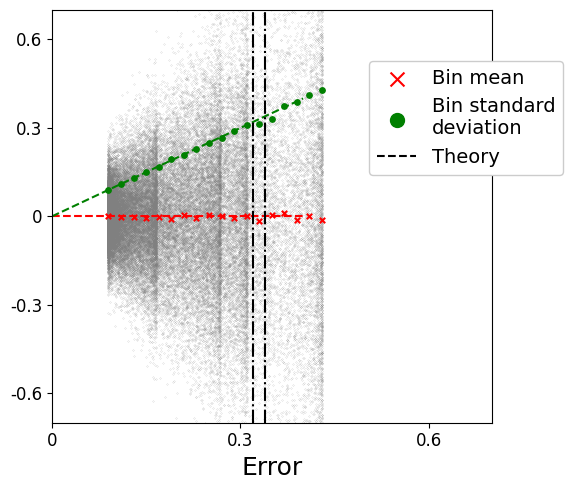

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5.8, 5))

variances = torch.flatten(torch.stack([observed_pred.variance]*n_gpr_samples))
errors = torch.flatten(samples - observed_pred.mean)

extended_reliablility_diagram(
    ax, 
    torch.sqrt(variances), 
    errors, 
    bin_size=0.02,
    max_value=0.7,
    max_value_theory=0.4,
    ticks=[0, 0.3, 0.6]
)
ax.set_xlabel('GPR standard deviation', fontsize=18) 
ax.set_xlabel('Error', fontsize=18)
ax = plot_legend(ax, fontsize=14, bbox_to_anchor=(0.7, 0.9))
ax.vlines(0.32, -0.7, 0.7, color='black', ls='-.');
ax.vlines(0.34, -0.7, 0.7, color='black', ls='-.');
plt.tight_layout()